# ♟️ Össze játszma vizualizációja

Ez a notebook a `02_analysis.py` által generált `stats.json` és a `03_stockfish_analysis.py` által generált `stockfish_analysis.json` fájlokat jeleníti meg interaktív Plotly grafikonokkal.

**Futtatás előtt:** Győződj meg róla, hogy a pipeline 1-3. lépései lefutottak.

---

In [1]:
import subprocess, sys, os

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)
import config

if not os.path.exists(config.STATS_JSON):
    print("stats.json nem található – pipeline futtatása...")
    result = subprocess.run(
        [sys.executable, os.path.join(root_dir, "src", "run_pipeline.py"), "--pgn", config.PGN_FILE],
        cwd=root_dir,
    )
    if result.returncode != 0:
        raise RuntimeError("Pipeline futtatása sikertelen! Ellenőrizd a PGN fájlt és a config.py-t.")
    print("✅ Pipeline kész.")
else:
    print(f"✅ Adatok már megvannak: {config.STATS_JSON}")

✅ Adatok már megvannak: D:\Workspace\chess-pgn-analysis\output\analysis\stats.json


## 1. Előkészítés és adatok betöltése

In [2]:
import sys, os
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)
import config

import json
import math
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

if not os.path.exists(config.STATS_JSON):
    raise FileNotFoundError(
        f"Nem található a statisztika fájl: {config.STATS_JSON}. "
        "Futtasd a pipeline 2. lépését: python src/run_pipeline.py --pgn sakkpartik.pgn"
    )
with open(config.STATS_JSON, encoding='utf-8') as f:
    stats = json.load(f)
sf_data = {}
if os.path.exists(config.STOCKFISH_JSON):
    with open(config.STOCKFISH_JSON, encoding='utf-8') as f:
        sf_data = json.load(f)


TOTAL = stats.get('total_games', 0)
print(f'   Stockfish elemzés: {"igen" if sf_data.get("evaluations") else "nem elérhető"}')

THEME = config.PLOT_THEME
print(f'✅ Adatok betöltve. Összes játszma: {TOTAL:,}')

   Stockfish elemzés: nem elérhető
✅ Adatok betöltve. Összes játszma: 1,377


## 2. Sakkjátszmák hossza

### 2.1 Az én játszmáim hossza (PLY-ban, azaz féllépésben)

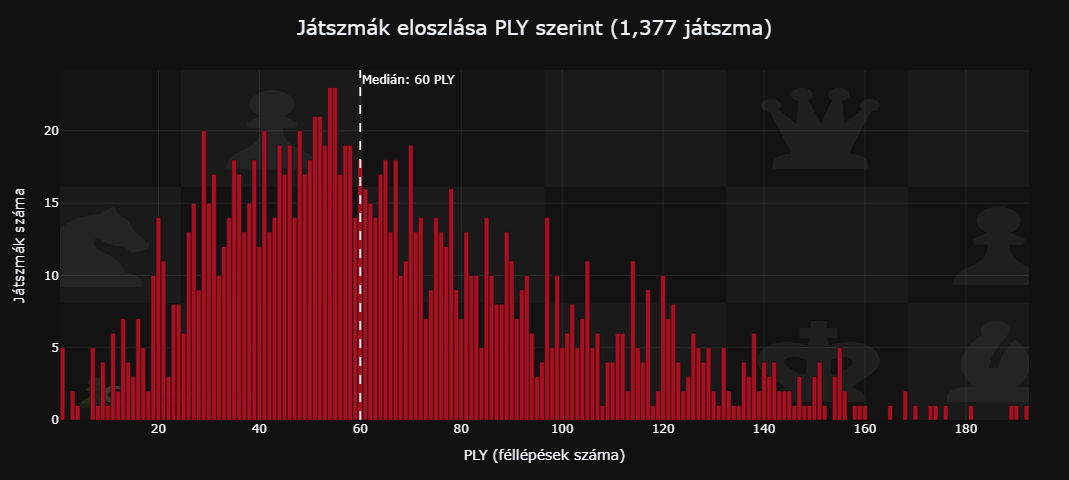

In [3]:
import base64, io
from PIL import Image

# Háttérkép base64-be
_img = Image.open(os.path.join(root_dir, 'notebooks', 'notebooks_src', 'bg1.png')).convert('RGB')
_buf = io.BytesIO()
_img.save(_buf, format='PNG')
_bg = 'data:image/png;base64,' + base64.b64encode(_buf.getvalue()).decode()

dist  = stats.get('move_count_dist', [])
mv_st = stats.get('move_stats', {})

if not dist:
    print('Nincs adat.')
else:
    df = pd.DataFrame(dist).sort_values('num_moves')

    fig = go.Figure(go.Bar(
        x=df['num_moves'],
        y=df['count'],
        marker_color='#A81022',
        hovertemplate='%{x} PLY → %{y:,} játszma<extra></extra>',
    ))

    median = mv_st.get('median_moves')
    if median is not None:
        fig.add_vline(
            x=float(median),
            line=dict(color='#ffffff', dash='dash', width=1.8),
            annotation_text=f'Medián: {float(median):.0f} PLY',
            annotation_font=dict(size=12, color='#ffffff'),
            annotation_position='top right',
        )

    fig.add_layout_image(dict(
        source=_bg,
        xref='paper', yref='paper',
        x=0, y=1, sizex=1, sizey=1,
        sizing='stretch',
        opacity=0.18,
        layer='below',
    ))

    fig.update_layout(
        title=dict(
            text=f'Játszmák eloszlása PLY szerint ({TOTAL:,} játszma)',
            font=dict(size=20),
            x=0.5,
            xanchor='center',
        ),
        xaxis=dict(
            title='PLY (féllépések száma)',
            gridcolor='rgba(255,255,255,0.08)',
            zeroline=False,
        ),
        yaxis=dict(
            title='Játszmák száma',
            gridcolor='rgba(255,255,255,0.08)',
            zeroline=False,
        ),
        template=THEME,
        plot_bgcolor='rgba(0,0,0,0)',
        height=480,
        bargap=0.06,
        showlegend=False,
        margin=dict(l=60, r=40, t=70, b=60),
    )

    fig.show()
    # fig.write_html(os.path.join(config.PLOTS_DIR, 'ply_distribution.html'))


### 2.2 Magnus Carlsen játszmáinak hossza (PLY-ban, azaz féllépésben)

OTB (over the board) profi játszmák 2001-től. Összehasonlítási alap a 2.1-es ábrához.

In [ ]:
import pandas as pd

_carlsen_parquet = os.path.join(root_dir, 'data', 'parquet', 'Carlsen_7484_games.parquet')
_CARLSEN_COLOR = '#1565C0'

if not os.path.exists(_carlsen_parquet):
    raise FileNotFoundError(
        f"Carlsen parquet nem található: {_carlsen_parquet}\n"
        "Futtasd: python src/run_pipeline.py --pgn data/pgns/Carlsen_7484_games.pgn"
    )

_df_c = pd.read_parquet(_carlsen_parquet, columns=['white', 'black', 'num_moves'])

# Carlsen neve auto-detektálás
_name_cnt = pd.concat([_df_c['white'], _df_c['black']]).value_counts()
_CARLSEN_NAME = _name_cnt.index[0]
print(f'Elemzett játékos: {_CARLSEN_NAME}')

# PLY eloszlás
_mask = _df_c['num_moves'] > 0
_total_ply = int(_mask.sum())
print(f'Beolvasva: {_total_ply} játszma')

df_carl = _df_c[_mask].groupby('num_moves').size().reset_index(name='count')
_med_carl = float(_df_c[_mask]['num_moves'].median())

fig_carl = go.Figure(go.Bar(
    x=df_carl['num_moves'],
    y=df_carl['count'],
    marker_color=_CARLSEN_COLOR,
    hovertemplate='%{x} PLY → %{y:,} játszma<extra></extra>',
))

fig_carl.add_vline(
    x=_med_carl,
    line=dict(color='#ffffff', dash='dash', width=1.8),
    annotation_text=f'Medián: {_med_carl:.0f} PLY',
    annotation_font=dict(size=12, color='#ffffff'),
    annotation_position='top right',
)

fig_carl.update_layout(
    title=dict(
        text=f'Magnus Carlsen játszmáinak eloszlása PLY szerint ({_total_ply:,} játszma)',
        font=dict(size=20),
        x=0.5, xanchor='center',
    ),
    xaxis=dict(
        title='PLY (féllépések száma)',
        gridcolor='rgba(255,255,255,0.08)',
        zeroline=False,
    ),
    yaxis=dict(
        title='Játszmák száma',
        gridcolor='rgba(255,255,255,0.08)',
        zeroline=False,
    ),
    template=THEME,
    plot_bgcolor='rgba(0,0,0,0)',
    height=480,
    bargap=0.06,
    showlegend=False,
    margin=dict(l=60, r=40, t=70, b=60),
)

fig_carl.show()

## 3. Megnyitás-repertoár térkép (Sankey-diagram)

**Olvasási útmutató:**
- A csomópontok **zöldje** = magas győzelmi arány, **pirosa** = alacsony győzelmi arány az adott vonalban.
- Az élek vastagsága arányos a lejátszott játszmák számával.
- Bal oldal: a játékos **színe**; közép: az **első lépés csoportja**; jobb: az egyes **ECO megnyitás-kódok**.
- Hover = részletes győzelem / vereség / döntetlen statisztika.


### 3.1 Saját megnyitás repertoárom

In [ ]:
import chess.pgn
import colorsys
from collections import defaultdict, Counter
import plotly.graph_objects as go
import os

# ── Paletta (HSL-interpoláció a sáros barna elkerüléséhez) ───────────────────
_BRAND = '#A81022'

_hls = lambda r, g, b: colorsys.rgb_to_hls(r / 255, g / 255, b / 255)
_H_MID, _L_MID, _S_MID = _hls(168,  16,  34)   # #A81022 – brand / 50%
_H_RED, _L_RED, _S_RED = _hls(231,  76,  60)   # #e74c3c – több vereség
_H_GRN, _L_GRN, _S_GRN = _hls( 39, 174,  96)   # #27ae60 – több győzelem

def _wr_color(wr_norm, alpha=0.88):
    """HSL-interpoláció normalizált [0,1] győzelmi arányra."""
    if wr_norm < 0.5:
        t, h2, l2, s2 = (0.5 - wr_norm) * 2, _H_RED, _L_RED, _S_RED
    else:
        t, h2, l2, s2 = (wr_norm - 0.5) * 2, _H_GRN, _L_GRN, _S_GRN
    dh = (h2 - _H_MID + 0.5) % 1.0 - 0.5
    h  = (_H_MID + dh * t) % 1.0
    l  = _L_MID + (l2 - _L_MID) * t
    s  = _S_MID + (s2 - _S_MID) * t
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})'

# ── ECO nevek (magyar) ────────────────────────────────────────────────────────
ECO_LABEL = {
    'D00': 'London-rendszer',       'D02': 'London var. (Nf3)',
    'D03': 'Torre-támadás',         'D10': 'Szláv védelem',
    'A40': 'Királyné gy. játék',    'A41': 'Régi indiai véd.',
    'A43': 'Régi Benoni',           'A45': 'Trompowsky',
    'A48': 'Királyindiai felállás', 'A80': 'Holland védelem',
    'A04': 'Réti-megnyitás var.',   'A00': 'Rendhagyó megnyitás',
    'B10': 'Caro-Kann véd.',        'B12': 'Caro-Kann előretolt',
    'B13': 'Caro-Kann csere',       'B15': 'Caro-Kann fővonal',
    'B18': 'Caro-Kann klasszikus',  'B00': 'Királygy. nyitás',
    'B01': 'Skandináv védelem',     'B07': 'Pirc védelem',
    'B50': 'Szicíliai var.',        'C41': 'Philidor védelem',
    'C50': 'Itáliai játszma',       'C45': 'Skót játszma',
}

# ── Hover szöveg ──────────────────────────────────────────────────────────────
def _hover(cnt, w, l, d):
    if cnt == 0:
        return 'Nincs adat'
    return (f'Összes játszma: <b>{cnt}</b><br>'
            f'Győzelem:  {w} ({w / cnt * 100:.0f}%)<br>'
            f'Vereség:   {l} ({l / cnt * 100:.0f}%)<br>'
            f'Döntetlen: {d} ({d / cnt * 100:.0f}%)')

# ── PGN betöltés + játékos detektálás ────────────────────────────────────────
_pgn = os.path.join(root_dir, 'data', 'pgns', 'sakkpartik.pgn')
if not os.path.exists(_pgn):
    _pgn = config.PGN_FILE

_nc = Counter()
with open(_pgn, encoding='utf-8') as f:
    while (g := chess.pgn.read_game(f)):
        _nc[g.headers.get('White', '')] += 1
        _nc[g.headers.get('Black', '')] += 1
PLAYER = _nc.most_common(1)[0][0]
print(f'Elemzett játékos: {PLAYER}')

# ── Adatgyűjtés (color → first-move group → eco → [W, L, D]) ─────────────────
_UCI_W = {'e2e4': '1.e4', 'd2d4': '1.d4', 'c2c4': '1.c4', 'g1f3': '1.♞f3'}
_UCI_B = {'e2e4': 'vs 1.e4', 'd2d4': 'vs 1.d4', 'c2c4': 'vs 1.c4', 'g1f3': 'vs 1.♞f3'}

_data = {
    'white': defaultdict(lambda: defaultdict(lambda: [0, 0, 0])),
    'black': defaultdict(lambda: defaultdict(lambda: [0, 0, 0])),
}

with open(_pgn, encoding='utf-8') as f:
    while (g := chess.pgn.read_game(f)):
        h      = g.headers
        white  = h.get('White', '')
        black  = h.get('Black', '')
        result = h.get('Result', '*')
        eco    = h.get('ECO', 'N/A')[:3]
        mvs    = list(g.mainline_moves())
        if not mvs:
            continue
        fm = str(mvs[0])

        if white == PLAYER:
            grp = _UCI_W.get(fm, 'Egyéb 1. lépés')
            wld = [int(result == '1-0'), int(result == '0-1'),
                   int(result not in ('1-0', '0-1'))]
            for i, v in enumerate(wld):
                _data['white'][grp][eco][i] += v

        elif black == PLAYER:
            grp = _UCI_B.get(fm, 'vs Egyéb')
            wld = [int(result == '0-1'), int(result == '1-0'),
                   int(result not in ('1-0', '0-1'))]
            for i, v in enumerate(wld):
                _data['black'][grp][eco][i] += v

# ── Sankey csomópontok és élek (1. menet: nyers adatok) ──────────────────────
MIN_ECO_GAMES = 8

_labels, _raw_wr, _hovers_node = [], [], []
_src, _tgt, _val, _lcol, _lhov = [], [], [], [], []

def _node(label, cnt, w, l, d):
    wr = w / cnt if cnt else None
    _labels.append(label)
    _raw_wr.append(wr)
    _hovers_node.append(_hover(cnt, w, l, d))
    return len(_labels) - 1

def _link(src, tgt, cnt, w, l, d):
    _src.append(src)
    _tgt.append(tgt)
    _val.append(cnt)
    _lcol.append('rgba(168, 16, 34, 0.35)')
    _lhov.append(_hover(cnt, w, l, d))

_wi = _node('♔ Fehérrel', 0, 0, 0, 0)
_bi = _node('♚ Feketével', 0, 0, 0, 0)
_wt = [0, 0, 0]
_bt = [0, 0, 0]

for _side, _ri, _tot in [('white', _wi, _wt), ('black', _bi, _bt)]:
    for grp, eco_dict in sorted(
            _data[_side].items(),
            key=lambda x: -sum(sum(v) for v in x[1].values())):
        gw = [sum(eco_dict[e][i] for e in eco_dict) for i in range(3)]
        gc = sum(gw)
        for i in range(3):
            _tot[i] += gw[i]
        gi = _node(grp, gc, *gw)
        _link(_ri, gi, gc, *gw)

        _other = [0, 0, 0]
        for eco, wld in sorted(eco_dict.items(), key=lambda x: -sum(x[1])):
            c = sum(wld)
            if c >= MIN_ECO_GAMES:
                name = ECO_LABEL.get(eco, eco)
                eco_idx = _node(f'{eco} · {name}', c, *wld)
                _link(gi, eco_idx, c, *wld)
            else:
                for i in range(3):
                    _other[i] += wld[i]
        oc = sum(_other)
        if oc > 0:
            oth_idx = _node(f'Egyéb ({oc} j.)', oc, *_other)
            _link(gi, oth_idx, oc, *_other)

# Gyökér csomópontok: összesítők frissítése (brand szín → None marad)
for _ri, _t in [(_wi, _wt), (_bi, _bt)]:
    tc = sum(_t)
    _raw_wr[_ri] = None
    _hovers_node[_ri] = _hover(tc, *_t)
    _labels[_ri] += f'  ({tc} j.)'

# ── 2. menet: relatív normalizálás → szín hozzárendelés ──────────────────────
# Minden megnyitás a saját adattartományán belül kap zöld/piros színt,
# így akkor is látható a különbség, ha mindenki <50% abszolút győzelmi arányú.
_known = [wr for wr in _raw_wr if wr is not None]
_min_wr, _max_wr = min(_known), max(_known)
_rng = max(_max_wr - _min_wr, 1e-6)

_colors = []
for wr in _raw_wr:
    if wr is None:
        _colors.append(_BRAND)
    else:
        _colors.append(_wr_color((wr - _min_wr) / _rng))

# ── Plotly Sankey ─────────────────────────────────────────────────────────────
fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=_labels,
        color=_colors,
        customdata=_hovers_node,
        hovertemplate='<b>%{label}</b><br>%{customdata}<extra></extra>',
        pad=22,
        thickness=20,
        line=dict(color='rgba(255,255,255,0.85)', width=0.8),
    ),
    link=dict(
        source=_src,
        target=_tgt,
        value=_val,
        color=_lcol,
        customdata=_lhov,
        hovertemplate='%{customdata}<extra></extra>',
    ),
))

fig.add_annotation(
    x=0.5, y=-0.065, xref='paper', yref='paper',
    text='Él vastagsága a játszmák számával egyenesen arányos, az élek jobb szélének színe a nyerési arányra utal az adott megnyitással',
    showarrow=False,
    font=dict(size=11, color='#888', family='Arial, sans-serif'),
    align='center',
)

fig.update_layout(
    title=dict(
        text=(
            '<b>Megnyitás-repertoár térkép</b>'
            f'<br><span style="font-size:13px; color:#888">{PLAYER} · {TOTAL:,} játszma</span>'
        ),
        font=dict(size=21, color='#1a1a1a', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center',
        y=0.985,
    ),
    font=dict(size=12, color='#222222', family='Arial, sans-serif'),
    paper_bgcolor='#ffffff',
    plot_bgcolor='#ffffff',
    height=780,
    margin=dict(l=24, r=24, t=100, b=68),
)

fig.show()
# fig.write_html(os.path.join(config.PLOTS_DIR, 'opening_sankey.html'))

### 3.2 Magnus Carlsen megnyitás repertoárja

In [ ]:
import colorsys
from collections import defaultdict
import pandas as pd
import plotly.graph_objects as go
import os

# ── Paletta (kék Carlsen-téma) ────────────────────────────────────────────────
_BRAND_C = '#1565C0'

_hls_c = lambda r, g, b: colorsys.rgb_to_hls(r / 255, g / 255, b / 255)
_H_MID_C, _L_MID_C, _S_MID_C = _hls_c( 21, 101, 192)
_H_RED_C, _L_RED_C, _S_RED_C = _hls_c(231,  76,  60)
_H_GRN_C, _L_GRN_C, _S_GRN_C = _hls_c( 39, 174,  96)

def _wr_color_c(wr_norm, alpha=0.88):
    """HSL-interpoláció normalizált [0,1] győzelmi arányra – kék téma."""
    if wr_norm < 0.5:
        t, h2, l2, s2 = (0.5 - wr_norm) * 2, _H_RED_C, _L_RED_C, _S_RED_C
    else:
        t, h2, l2, s2 = (wr_norm - 0.5) * 2, _H_GRN_C, _L_GRN_C, _S_GRN_C
    dh = (h2 - _H_MID_C + 0.5) % 1.0 - 0.5
    h  = (_H_MID_C + dh * t) % 1.0
    l  = _L_MID_C + (l2 - _L_MID_C) * t
    s  = _S_MID_C + (s2 - _S_MID_C) * t
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})'

# ── ECO nevek (Carlsen repertoárjához igazítva) ───────────────────────────────
ECO_LABEL_C = {
    'C50': 'Olasz játszma',        'C60': 'Ruy Lopez',
    'C65': 'Berlin véd.',          'C67': 'Berlin fővonal',
    'C42': 'Orosz védelem',        'C45': 'Skót játszma',
    'C41': 'Philidor véd.',        'C40': 'Király gy. nyitás',
    'B20': 'Szicíliai',            'B60': 'Szicíliai Najdorf',
    'B70': 'Szicíliai sárkány',    'B80': 'Szicíliai Scheveningen',
    'B90': 'Szicíliai Najdorf fővonal',
    'B10': 'Caro-Kann',            'B12': 'Caro-Kann előretolt',
    'B13': 'Caro-Kann csere',
    'C00': 'Francia véd.',         'C11': 'Francia Tarrasch',
    'D00': 'London-rendszer',      'D10': 'Szláv véd.',
    'D20': 'Királyné gambit',      'D37': 'QGD klasszikus',
    'D40': 'QGD félszláv',         'D43': 'Félszláv Botvinnik',
    'D85': 'Grünfeld csere',       'D86': 'Grünfeld',
    'D90': 'Grünfeld fővonal',
    'E00': 'Katalán',              'E06': 'Katalán zárt',
    'E15': 'Királynő indiai',      'E20': 'Nimzo-indiai',
    'E32': 'Nimzo-indiai klasszikus',
    'E60': 'Király indiai',        'E67': 'Király indiai fianchetto',
    'A10': 'Angol megnyitás',      'A13': 'Angol megnyitás',
    'A04': 'Réti-megnyitás',       'A05': 'Réti-megnyitás',
}

# ── Hover szöveg ──────────────────────────────────────────────────────────────
def _hover_c(cnt, w, l, d):
    if cnt == 0:
        return 'Nincs adat'
    return (f'Összes játszma: <b>{cnt}</b><br>'
            f'Győzelem:  {w} ({w / cnt * 100:.0f}%)<br>'
            f'Vereség:   {l} ({l / cnt * 100:.0f}%)<br>'
            f'Döntetlen: {d} ({d / cnt * 100:.0f}%)')

# ── Parquet betöltés ──────────────────────────────────────────────────────────
_carlsen_parquet = os.path.join(root_dir, 'data', 'parquet', 'Carlsen_7484_games.parquet')
_df_cs = pd.read_parquet(_carlsen_parquet, columns=['white', 'black', 'result', 'eco', 'moves_uci'])
_df_cs['eco3']       = _df_cs['eco'].str[:3].fillna('N/A')
_df_cs['first_move'] = _df_cs['moves_uci'].str.split().str[0].fillna('')
_df_cs = _df_cs[_df_cs['first_move'] != '']

# Carlsen neve (az előző cellából, vagy újra-detektálás)
CARLSEN = _CARLSEN_NAME
_total_c = len(_df_cs)
print(f'Elemzett játékos: {CARLSEN}')
print(f'Beolvasva: {_total_c} játszma')

# ── Adatgyűjtés ───────────────────────────────────────────────────────────────
_UCI_W_C = {'e2e4': '1.e4', 'd2d4': '1.d4', 'c2c4': '1.c4', 'g1f3': '1.Nf3'}
_UCI_B_C = {'e2e4': 'vs 1.e4', 'd2d4': 'vs 1.d4', 'c2c4': 'vs 1.c4', 'g1f3': 'vs 1.Nf3'}

_data_c = {
    'white': defaultdict(lambda: defaultdict(lambda: [0, 0, 0])),
    'black': defaultdict(lambda: defaultdict(lambda: [0, 0, 0])),
}

for row in _df_cs.itertuples(index=False):
    eco    = row.eco3
    fm     = row.first_move
    result = row.result

    if row.white == CARLSEN:
        grp = _UCI_W_C.get(fm, 'Egyéb 1. lépés')
        wld = [int(result == '1-0'), int(result == '0-1'),
               int(result not in ('1-0', '0-1'))]
        for i, v in enumerate(wld):
            _data_c['white'][grp][eco][i] += v
    elif row.black == CARLSEN:
        grp = _UCI_B_C.get(fm, 'vs Egyéb')
        wld = [int(result == '0-1'), int(result == '1-0'),
               int(result not in ('1-0', '0-1'))]
        for i, v in enumerate(wld):
            _data_c['black'][grp][eco][i] += v

# ── Sankey felépítése (1. menet: nyers adatok) ────────────────────────────────
MIN_ECO_C = 15

_labels_c, _raw_wr_c, _hovers_nd_c = [], [], []
_src_c, _tgt_c, _val_c, _lcol_c, _lhov_c = [], [], [], [], []

def _node_c(label, cnt, w, l, d):
    wr = w / cnt if cnt else None
    _labels_c.append(label)
    _raw_wr_c.append(wr)
    _hovers_nd_c.append(_hover_c(cnt, w, l, d))
    return len(_labels_c) - 1

def _link_c(src, tgt, cnt, w, l, d):
    _src_c.append(src); _tgt_c.append(tgt); _val_c.append(cnt)
    _lcol_c.append('rgba(21,101,192,0.32)')
    _lhov_c.append(_hover_c(cnt, w, l, d))

_wi_c = _node_c('♔ Fehérrel', 0, 0, 0, 0)
_bi_c = _node_c('♚ Feketével', 0, 0, 0, 0)
_wt_c = [0, 0, 0]
_bt_c = [0, 0, 0]

for _side, _ri, _tot in [('white', _wi_c, _wt_c), ('black', _bi_c, _bt_c)]:
    for grp, eco_dict in sorted(
            _data_c[_side].items(),
            key=lambda x: -sum(sum(v) for v in x[1].values())):
        gw = [sum(eco_dict[e][i] for e in eco_dict) for i in range(3)]
        gc = sum(gw)
        for i in range(3):
            _tot[i] += gw[i]
        gi = _node_c(grp, gc, *gw)
        _link_c(_ri, gi, gc, *gw)

        _other = [0, 0, 0]
        for eco, wld in sorted(eco_dict.items(), key=lambda x: -sum(x[1])):
            c = sum(wld)
            if c >= MIN_ECO_C:
                name = ECO_LABEL_C.get(eco, eco)
                eco_idx = _node_c(f'{eco} · {name}', c, *wld)
                _link_c(gi, eco_idx, c, *wld)
            else:
                for i in range(3):
                    _other[i] += wld[i]
        oc = sum(_other)
        if oc > 0:
            oth_idx = _node_c(f'Egyéb ({oc} j.)', oc, *_other)
            _link_c(gi, oth_idx, oc, *_other)

for _ri, _t in [(_wi_c, _wt_c), (_bi_c, _bt_c)]:
    tc = sum(_t)
    _raw_wr_c[_ri] = None
    _hovers_nd_c[_ri] = _hover_c(tc, *_t)
    _labels_c[_ri] += f'  ({tc} j.)'

# ── 2. menet: relatív normalizálás ────────────────────────────────────────────
_known_c = [wr for wr in _raw_wr_c if wr is not None]
_min_wr_c, _max_wr_c = min(_known_c), max(_known_c)
_rng_c = max(_max_wr_c - _min_wr_c, 1e-6)

_colors_c = []
for wr in _raw_wr_c:
    if wr is None:
        _colors_c.append(_BRAND_C)
    else:
        _colors_c.append(_wr_color_c((wr - _min_wr_c) / _rng_c))

# ── Plotly Sankey ─────────────────────────────────────────────────────────────
fig_cs = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=_labels_c,
        color=_colors_c,
        customdata=_hovers_nd_c,
        hovertemplate='<b>%{label}</b><br>%{customdata}<extra></extra>',
        pad=22, thickness=20,
        line=dict(color='rgba(255,255,255,0.85)', width=0.8),
    ),
    link=dict(
        source=_src_c, target=_tgt_c, value=_val_c,
        color=_lcol_c, customdata=_lhov_c,
        hovertemplate='%{customdata}<extra></extra>',
    ),
))

fig_cs.add_annotation(
    x=0.5, y=-0.065, xref='paper', yref='paper',
    text='Él vastagsága a játszmák számával egyenesen arányos',
    showarrow=False,
    font=dict(size=11, color='#888', family='Arial, sans-serif'),
    align='center',
)

fig_cs.update_layout(
    title=dict(
        text=(
            '<b>Magnus Carlsen megnyitás-repertoár térképe</b>'
            f'<br><span style="font-size:13px; color:#888">{CARLSEN} · {_total_c:,} játszma</span>'
        ),
        font=dict(size=21, color='#1a1a1a', family='Arial, sans-serif'),
        x=0.5, xanchor='center', y=0.985,
    ),
    font=dict(size=12, color='#222222', family='Arial, sans-serif'),
    paper_bgcolor='#ffffff',
    plot_bgcolor='#ffffff',
    height=780,
    margin=dict(l=24, r=24, t=100, b=68),
)

fig_cs.show()
# fig_cs.write_html(os.path.join(config.PLOTS_DIR, 'carlsen_sankey.html'))